# Iris Flower Classification
This notebook explores the classic Iris dataset and trains a machine learning model to classify iris flower species based on physical measurements.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Set plotting aesthetics
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Load and Explore the Dataset

In [3]:
# Load the dataset from local CSV file
df = pd.read_csv('iris.csv')

# Inspect structural details
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# Drop unnecessary ID column if present
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

# Check target class balance
print(df['Species'].value_counts())
df.describe()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 2. Exploratory Data Analysis (EDA)
Visualizing relationship patterns among the structural flower dimensions.

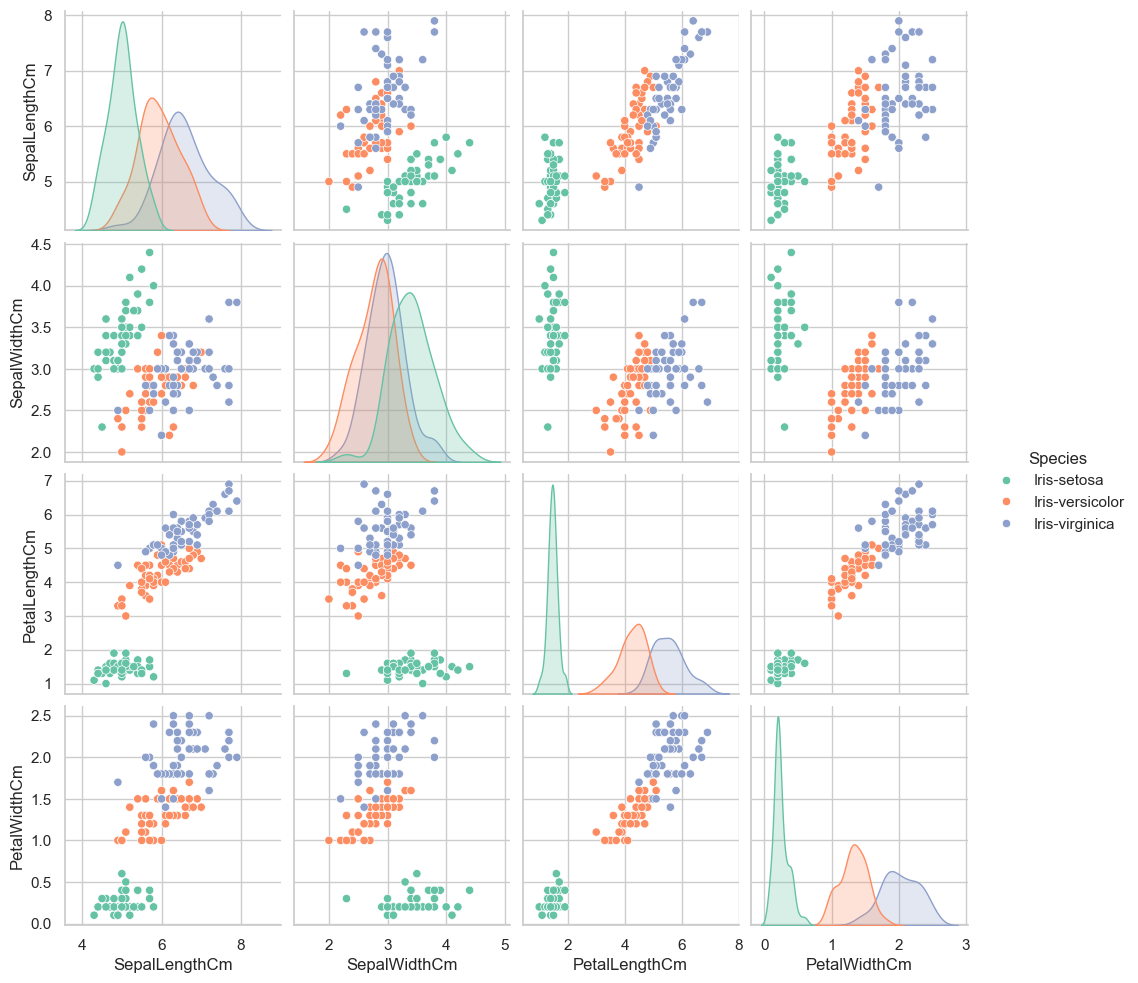

In [5]:
# Pairplot to view features distribution grouped by target species
sns.pairplot(df, hue='Species', palette='Set2')
plt.show()

## 3. Data Preprocessing
Splitting data into target arrays and feature matrices, then mapping the categorical text classes.

In [6]:
X = df.drop(columns=['Species'])
y = df['Species']

# Convert categorical tags into distinct numerical values
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Stratified partition into train and test splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (120, 4)
Testing set shape: (30, 4)


## 4. Model Training & Evaluation
Fitting a Random Forest Classifier and assessing its performance traits.

In [7]:
# Initialize classifier with controlled initialization states
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Generate inference predictions
y_pred = model.predict(X_test)

# Calculate objective metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Classification Accuracy: {accuracy:.4f}\n")
print("Detailed Metric Summary:\n", classification_report(y_test, y_pred, target_names=le.classes_))

Overall Classification Accuracy: 0.9000

Detailed Metric Summary:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



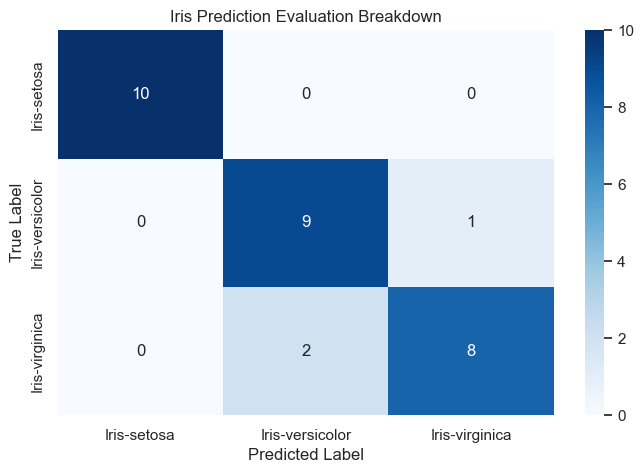

In [8]:
# Construct and plot structured confusion matrix metrics
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Iris Prediction Evaluation Breakdown')
plt.show()